# Diffusion T=1000, 500 epoch 학습 후 생성 샘플

In [1]:
import os
import subprocess

GPU_ID = None  # None이면 아래에서 가장 한가한 GPU를 자동 선택. 고정하려면 "0" / "1" / "2"처럼 지정


def pick_free_gpu():
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=index,memory.used,utilization.gpu", "--format=csv,noheader,nounits"]
    ).decode()
    rows = [tuple(int(v) for v in line.split(",")) for line in out.strip().splitlines()]
    for idx, mem, util in rows:
        print(f"  GPU {idx}: memory {mem} MiB, util {util}%")
    return str(min(rows, key=lambda r: (r[1], r[2]))[0])


if GPU_ID is None:
    GPU_ID = pick_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID
print("사용 GPU:", GPU_ID)
RUN_SEEDS = [0]  # 미리보기용: seed 0만. 여러 seed를 보려면 [0, 1, 2]처럼

  GPU 0: memory 460 MiB, util 3%
사용 GPU: 0


## 0. 라이브러리 & 공용 모듈

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path
_d = Path.cwd().resolve()
while not (_d / "models.py").exists():
    if _d.parent == _d:
        raise FileNotFoundError("상위 폴더 어디에도 models.py가 없습니다")
    _d = _d.parent
if str(_d) not in sys.path:
    sys.path.insert(0, str(_d))
print("공용 모듈 경로:", _d)

import os
import time
from collections import Counter

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from models import Unet, Classifier
from utils import (
    set_seed, DEVICE, SEEDS, EMA,
    evaluate_classifier, metrics_to_rows, append_result_rows,
)
from diffusion import GaussianDiffusion
from data import (
    build_imbalanced_group_split, crop_group, CachedDataset, CachedSubset, BalancedDataset,
    generate_balanced_fake, draw_from_pool,
)

SEEDS = [s for s in SEEDS if s in RUN_SEEDS]

print("device:", DEVICE)
print("모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)")


공용 모듈 경로: C:\Users\user\OneDrive\code\diffusion\7_diffusion_image_filter
device: cuda
모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)


## 1. 데이터 (exp1과 같은 원본 단위 분할)

In [4]:
image_size = 64
channels = 3
batch_size = 40
num_classes = 3

data_root = os.environ.get("DATA_ROOT", "../../data/AM_image_data_3split")  # 원본 213x460 (한 장을 3조각 낸 k0/k1/k2) → 아래 transform에서 64x64로 resize

CLASS_NAMES = ["Normal", "Underfill_50FR", "Underfill_Fan"]  # ImageFolder는 폴더명 알파벳순으로 라벨을 매김 (Normal=0, Underfill_50FR=1, Underfill_Fan=2)

train_counts = {0: 800, 1: 80, 2: 80}
test_counts = {0: 100, 1: 100, 2: 100}

transform = T.Compose([
    T.Resize((image_size, image_size)),
    T.ToTensor(),
    T.Lambda(lambda t: (t * 2) - 1),  # [0,1] -> [-1,1]
])

full_dataset = ImageFolder(root=data_root, transform=transform)
assert full_dataset.classes == CLASS_NAMES, full_dataset.classes

full_cached = CachedDataset(full_dataset)


def set_split(seed):
    global train_indices, test_indices, train_dataset, test_dataset
    global train_loader, test_loader, train_labels, test_labels
    train_indices, test_indices = build_imbalanced_group_split(full_dataset, train_counts, test_counts, seed=seed)
    leaked = ({crop_group(full_dataset.samples[i][0]) for i in train_indices}
              & {crop_group(full_dataset.samples[i][0]) for i in test_indices})
    assert not leaked, f"같은 원본이 train/test에 모두 있음: {sorted(leaked)[:5]}"

    train_dataset = CachedSubset(full_cached, train_indices)
    test_dataset = CachedSubset(full_cached, test_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                               pin_memory=(DEVICE == "cuda"))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                              pin_memory=(DEVICE == "cuda"))

    train_labels = [full_dataset.samples[i][1] for i in train_indices]
    test_labels = [full_dataset.samples[i][1] for i in test_indices]


set_split(0)  # 미리보기/학습량 기준(BASELINE_STEPS) 계산용 초기 분할
print("SEEDS:", SEEDS)
print("Train label distribution:", Counter(train_labels))
print("Test  label distribution:", Counter(test_labels))


SEEDS: [0]
Train label distribution: Counter({0: 800, 1: 80, 2: 80})
Test  label distribution: Counter({0: 100, 1: 100, 2: 100})


## 2. Diffusion 설정 & 학습 함수 (exp1과 같음)

In [5]:
timesteps = 1000
ddpm = GaussianDiffusion(timesteps=timesteps, image_size=image_size, channels=channels)
SAMPLE_STEPS = [2, 10, 30, 50, 100, 300, 500]

DIFFUSION_EPOCHS_REF = 500
EMA_DECAY = 0.999


In [6]:
def train_diffusion(seed, epochs=None):
    epochs = epochs or DIFFUSION_EPOCHS_REF
    set_seed(seed)
    device = DEVICE

    diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(device)
    opt_g = torch.optim.Adam(diffusion.parameters(), lr=2e-4)
    diffusion_loss_fn = nn.MSELoss()
    ema = EMA(diffusion, decay=EMA_DECAY)
    t0 = time.time()

    pbar = tqdm(range(epochs), desc=f"[Diffusion seed{seed}]")
    for epoch in pbar:
        diffusion.train()
        epoch_losses = []
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            t = torch.randint(0, timesteps, (x.size(0),), device=device)
            noise = torch.randn_like(x)
            x_noisy = ddpm.q_sample(x, t, noise)

            pred_noise = diffusion(x_noisy, t, y)
            loss = diffusion_loss_fn(pred_noise, noise)

            opt_g.zero_grad()
            loss.backward()
            opt_g.step()
            ema.update(diffusion)

            epoch_losses.append(loss.item())

        pbar.set_postfix(diff=f"{np.mean(epoch_losses):.4f}")

        if (epoch + 1) % 100 == 0 or epoch == epochs - 1:
            tqdm.write(f"[Diffusion seed{seed}] Epoch {epoch+1}/{epochs} Diff={np.mean(epoch_losses):.4f} "
                  f"elapsed={time.time()-t0:.1f}s")

    return diffusion, ema


DIFFUSION_PATH = "checkpoints/diffusion_epoch_500_seed{seed}.pt"
DIFFUSION_EMA_PATH = "checkpoints/diffusion_epoch_500_ema_seed{seed}.pt"
os.makedirs("checkpoints", exist_ok=True)


def load_or_train_diffusion(seed):
    path, ema_path = DIFFUSION_PATH.format(seed=seed), DIFFUSION_EMA_PATH.format(seed=seed)
    if os.path.exists(path) and os.path.exists(ema_path):
        diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(DEVICE)
        diffusion.load_state_dict(torch.load(path, map_location=DEVICE))
        ema = EMA(diffusion, decay=EMA_DECAY)
        ema.model.load_state_dict(torch.load(ema_path, map_location=DEVICE))
        print(f"[Diffusion seed{seed}] 학습 건너뜀: {path}, {ema_path} 로드")
        return diffusion, ema, False
    diffusion, ema = train_diffusion(seed)
    return diffusion, ema, True


## 3. 학습 (체크포인트가 있으면 불러옴)

In [7]:
models_ema = {}
for seed in SEEDS:
    set_split(seed)  # exp1과 같은 분할에서 학습해야 exp1이 이 체크포인트를 그대로 쓸 수 있다
    print(f"\n===== Diffusion DDPM T={timesteps}, {DIFFUSION_EPOCHS_REF} epoch | Seed {seed} =====")
    diffusion, ema, trained = load_or_train_diffusion(seed)
    if trained:
        torch.save(diffusion.state_dict(), DIFFUSION_PATH.format(seed=seed))
        torch.save(ema.model.state_dict(), DIFFUSION_EMA_PATH.format(seed=seed))
        print(f"[Diffusion seed{seed}] 저장: {DIFFUSION_PATH.format(seed=seed)}, {DIFFUSION_EMA_PATH.format(seed=seed)}")
    models_ema[seed] = ema.model



===== Diffusion DDPM T=1000, 500 epoch | Seed 0 =====
[Diffusion seed0] 학습 건너뜀: diffusion_epoch_500_seed0.pt, diffusion_epoch_500_ema_seed0.pt 로드


## 4. 생성 샘플 보기

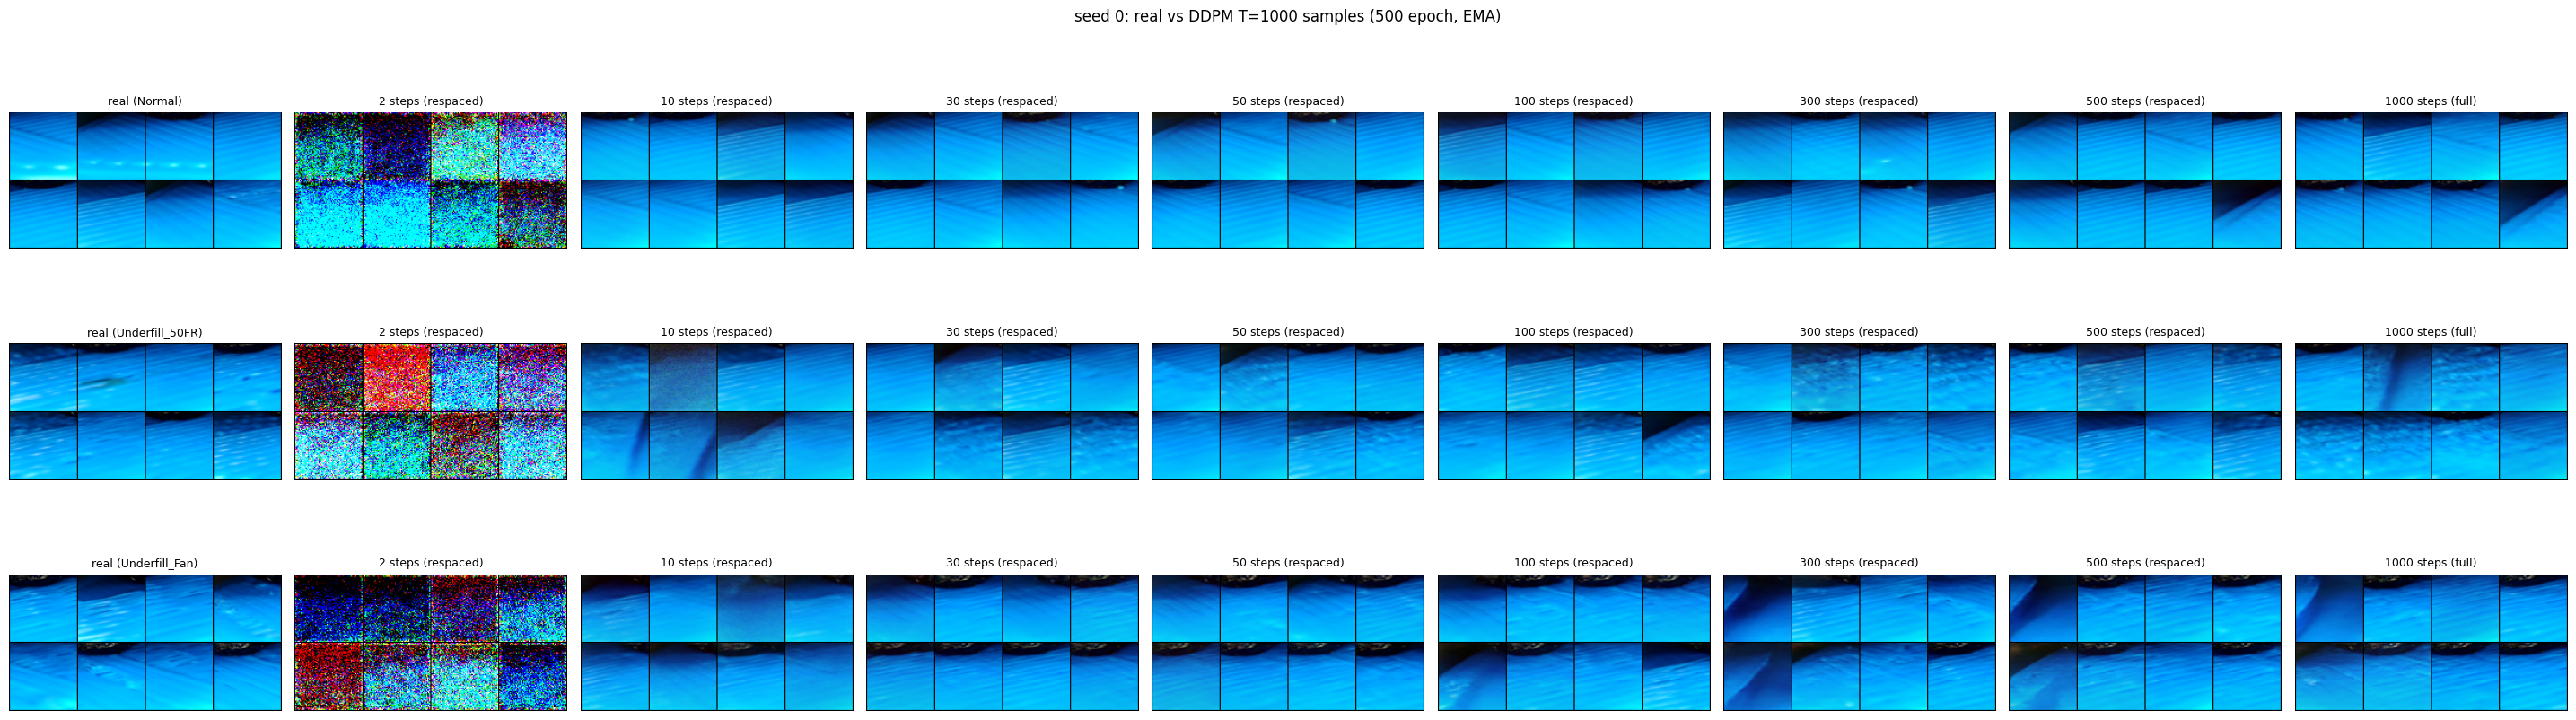

In [ ]:
N_SHOW = 8  # 클래스당 보여줄 장 수
SHOW_STEPS = SAMPLE_STEPS + [timesteps]  # 마지막은 respacing 없는 전체 DDPM (sample_ddpm과 같음)


def denorm(x):
    return (x + 1) / 2


def to_grid(x, nrow):
    return make_grid(denorm(x).clamp(0, 1).cpu(), nrow=nrow, padding=1).permute(1, 2, 0)


for seed in SEEDS:
    set_split(seed)
    model = models_ema[seed]
    ncol = 1 + len(SHOW_STEPS)
    fig, axes = plt.subplots(num_classes, ncol, figsize=(3.2 * ncol, 3.0 * num_classes), squeeze=False)
    for cls in range(num_classes):
        real_idx = [i for i, y in enumerate(train_labels) if y == cls][:N_SHOW]
        real = torch.stack([train_dataset[i][0] for i in real_idx])
        axes[cls, 0].imshow(to_grid(real, nrow=4))
        axes[cls, 0].set_title(f"real ({CLASS_NAMES[cls]})", fontsize=9)
        y_vis = torch.full((N_SHOW,), cls, device=DEVICE, dtype=torch.long)
        for j, steps in enumerate(SHOW_STEPS, start=1):
            set_seed(seed * 100 + cls)  # 스텝 수가 달라도 같은 초기 노이즈
            x = ddpm.sample_ddpm_respaced(model, y_vis, DEVICE, steps=steps)
            axes[cls, j].imshow(to_grid(x, nrow=4))
            axes[cls, j].set_title(f"{steps} steps" + (" (full)" if steps == timesteps else " (respaced)"), fontsize=9)
    for ax in axes.flat:
        ax.axis("off")
    plt.suptitle(f"seed {seed}: real vs DDPM T={timesteps} samples ({DIFFUSION_EPOCHS_REF} epoch, EMA)")
    plt.tight_layout()
    plt.show()  
